In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split  # only for splitting
import matplotlib.pyplot as plt

In [27]:
dataset_path = "/home/deep/Documents/COVID"
img_size = (224, 224)  # Resize images for simplicity
class_labels = ['COVID positive', 'COVID negative']

In [5]:
def load_images(path, label):
    images = []
    labels = []
    for file in os.listdir(path):
        if file.endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(path, file)
            img = Image.open(img_path).convert('L')  # Convert to grayscale
            img = img.resize(img_size)
            images.append(np.array(img).flatten())
            labels.append(label)
    return images, labels


In [7]:
X = []
y = []

In [9]:
for label_idx, class_name in enumerate(class_labels):
    class_path = os.path.join(dataset_path, class_name)
    imgs, labels = load_images(class_path, label_idx)
    X.extend(imgs)
    y.extend(labels)

X = np.array(X)
y = np.array(y)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [63]:
class NaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for cls in self.classes:
            X_c = X[y == cls]
            self.mean[cls] = np.mean(X_c, axis=0)
            self.var[cls] = np.var(X_c, axis=0) + 1e-6  # avoid divide-by-zero
            self.priors[cls] = X_c.shape[0] / X.shape[0]

    def gaussian_pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for cls in self.classes:
                prior = np.log(self.priors[cls])
                conditional = np.sum(np.log(self.gaussian_pdf(cls, x)))
                posteriors.append(prior + conditional)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

In [65]:
model = NaiveBayes()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [66]:
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7335


In [67]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_labels))



Confusion Matrix:
 [[215  29]
 [104 151]]

Classification Report:
                 precision    recall  f1-score   support

COVID negative       0.67      0.88      0.76       244
COVID positive       0.84      0.59      0.69       255

      accuracy                           0.73       499
     macro avg       0.76      0.74      0.73       499
  weighted avg       0.76      0.73      0.73       499



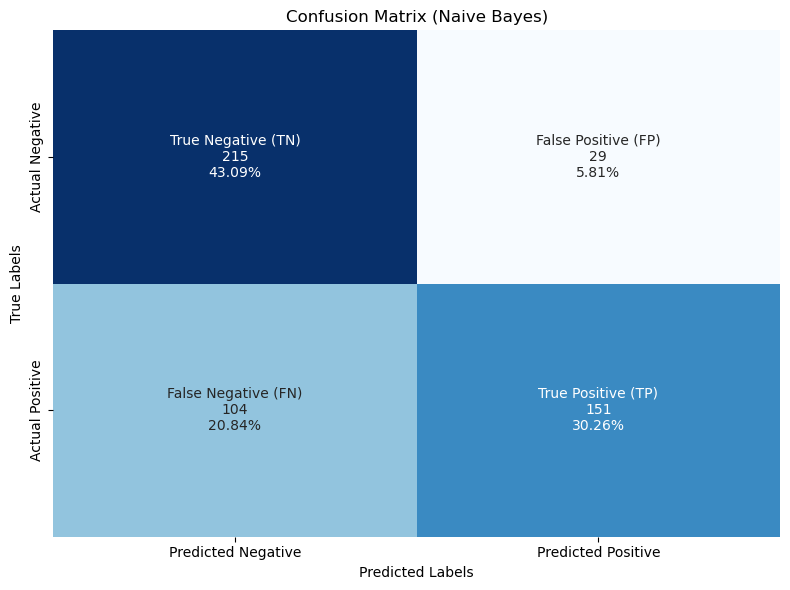


From Confusion Matrix:
Precision : 0.8389
Recall :    0.5922
F1 Score :  0.6943


In [71]:
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    group_names = ['True Negative (TN)', 'False Positive (FP)',
                   'False Negative (FN)', 'True Positive (TP)']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

    labels = [f"{name}\n{count}\n{percent}" for name, count, percent in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

# Call the function
plot_confusion_matrix(cm, title="Confusion Matrix (Naive Bayes)")

def compute_metrics_from_cm(cm):
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

    return precision, recall, f1

# Calculate metrics
precision, recall, f1 = compute_metrics_from_cm(cm)
print(f"\nFrom Confusion Matrix:")
print(f"Precision : {precision:.4f}")
print(f"Recall :    {recall:.4f}")
print(f"F1 Score :  {f1:.4f}")
